In [8]:
import pandas as pd
import numpy as np

# Load data
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

# Add labels
fake["label"] = 0
real["label"] = 1

# Combine
df = pd.concat([fake, real])
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,"Obama vetoes Sept. 11 Saudi bill, sets up show...",WASHINGTON (Reuters) - President Barack Obama ...,politicsNews,"September 23, 2016",1
1,Trump Is HOPING People Won’t See This Video T...,CNN talked to the man who conducted the study ...,News,"January 25, 2017",0
2,U.S. senator says panel could take up Russia s...,WASHINGTON (Reuters) - The Republican chairman...,politicsNews,"May 25, 2017",1
3,Abadi defends role of Iranian-backed paramilta...,BAGHDAD (Reuters) - Iraqi Prime Minister Haide...,worldnews,"October 23, 2017",1
4,JUDGE NAPOLITANO Drops A Bomb About Obama’s Su...,Judge Napolitano spoke out today about the un...,politics,"May 15, 2017",0


TEXT PROCESSING

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["text"]
y = df["label"]

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X = vectorizer.fit_transform(X)

In [10]:
print(y.value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [11]:
# Balance dataset
df = df.groupby('label').apply(lambda x: x.sample(n=5000, random_state=42)).reset_index(drop=True)

/tmp/ipykernel_14434/2521138617.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label').apply(lambda x: x.sample(n=5000, random_state=42)).reset_index(drop=True)


In [12]:
#IMPROVE MODEL
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

TRAIN MODEL

In [13]:
test_text = "Government announces new policy for economic growth"
vectorized = vectorizer.transform([test_text])
print(model.predict(vectorized))

[0]


EVALUATION

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9839643652561247
[[4631   75]
 [  69 4205]]


ADD CONFUSION MATRIX

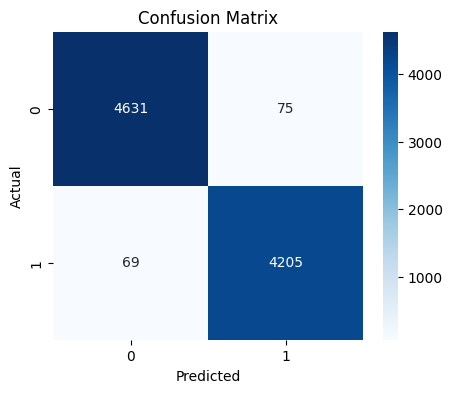

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

SAVE MODEL

In [17]:
joblib.dump(model, "fake_news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']